# Задача на 3-ом шаге урока

**Застекай их**

Объявите модель StackingClassifier(), которая в качестве базовых моделей будет принимать список estimators, а в качестве метамодели использует LogisticRegression().

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier

train (2337, 17)


,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,mean_rating,distance_sum,rating_min,speed_max,user_ride_quality_median,deviation_normal_count,user_uniq
2284,k-1735337t,VW Polo VI,economy,petrol,6.58,2015,89285,2018,60.42,another_bug,4.815632,1.333465e+07,0.1,200.000000,3.124202,174,174
1181,u12808660Q,Smart ForTwo,economy,petrol,4.62,2016,103187,2018,42.60,wheel_shake,4.594138,8.887761e+06,0.1,127.584531,-19.618085,174,171
1844,M21896536R,Kia Rio,economy,petrol,3.44,2014,62922,2016,49.00,wheel_shake,4.762759,1.119532e+07,0.1,119.495418,1.358826,174,169


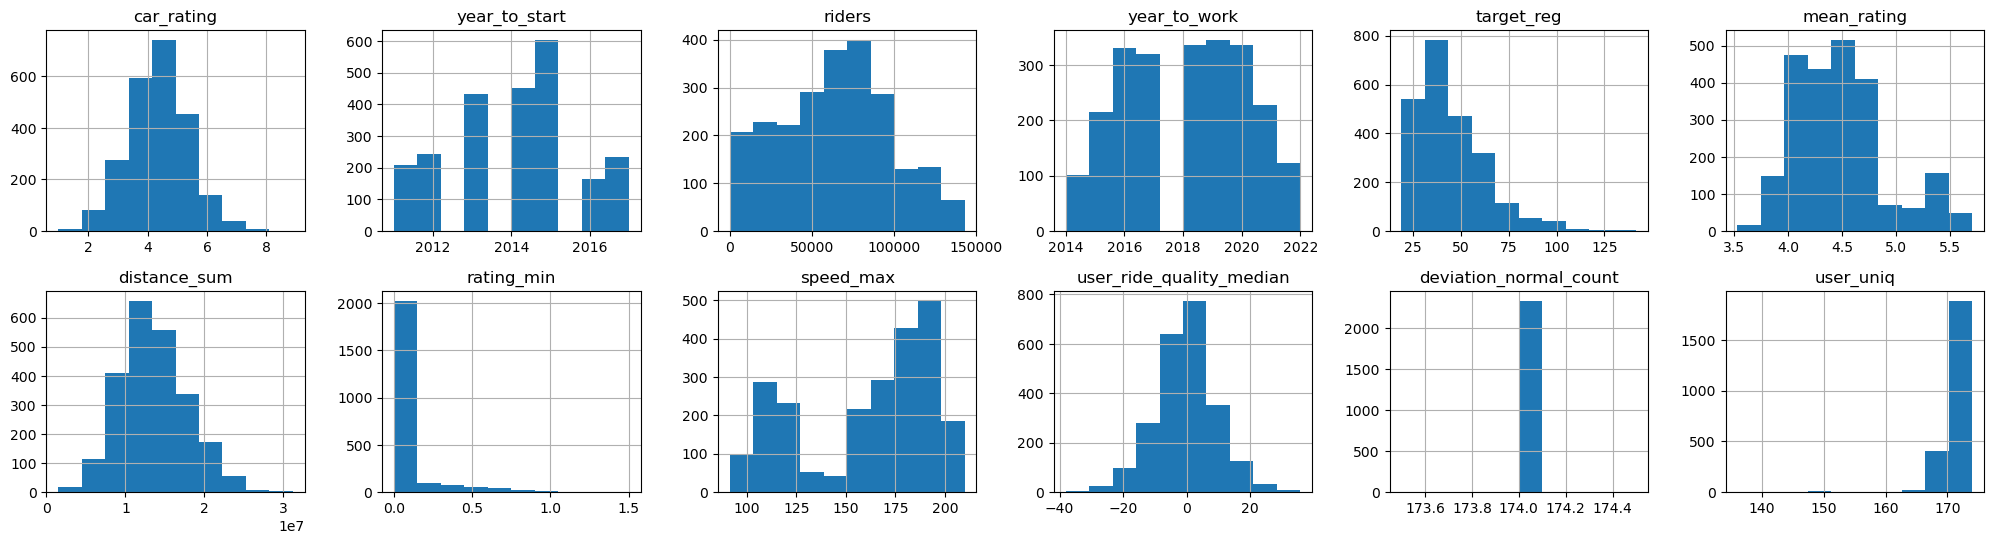

In [3]:
path = "../data/quickstart_train.csv"
train = pd.read_csv(path)

print("train", train.shape)
train.hist(figsize=(25, 6), layout=(-1, 6))
train.sample(3)

In [4]:
cat_features = ["model", "car_type", "fuel_type"]  # Выделяем категориальные признаки
targets = ["target_class", "target_reg"]
features2drop = ["car_id"]  # эти фичи будут удалены

# Отбираем итоговый набор признаков для использования моделью
filtered_features = [i for i in train.columns if (i not in targets and i not in features2drop)]
num_features = [i for i in filtered_features if i not in cat_features]

print("cat_features", cat_features)
print("num_features", len(num_features))
print("targets", targets)

for c in cat_features:  # Избавлеямся от NaN'ов
    train[c] = train[c].astype(str)

cat_features ['model', 'car_type', 'fuel_type']
num_features 11
targets ['target_class', 'target_reg']


In [5]:
from sklearn.preprocessing import LabelEncoder

for col in cat_features:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])

In [6]:
from sklearn.model_selection import train_test_split

X = train[filtered_features].drop(targets, axis=1, errors="ignore")
y = train["target_class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.metrics import f1_score

cb = CatBoostClassifier(verbose=0, random_state=42)
cb.fit(X_train, y_train)
y_pred = cb.predict(X_test)

f1_score(y_test, y_pred, average='micro')

0.7649572649572649

In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Создаём экземпляры моделей с параметрами
estimators = [
    ('catboost', CatBoostClassifier(verbose=0, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('xgboost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
]

final_estimator = Pipeline([
    # ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

# Собираем StackingClassifier
meta_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    # final_estimator=RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1),
    cv=3,  # опционально: кросс-валидация для обучения базовых моделей
    n_jobs=-1
)

In [9]:
meta_model.fit(X_train, y_train)

StackingClassifier(cv=3,
                   estimators=[('catboost',
                                <catboost.core.CatBoostClassifier object at 0x0000016DE9A5B080>),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=Pipeline(steps=[('lr',
                                                    LogisticRegression())]),
                   n_jobs=-1)

In [10]:
y_pred = meta_model.predict(X_test)

f1_score(y_test, y_pred, average='micro')

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid

0.7649572649572649

In [11]:
from sklearn.inspection import permutation_importance


# Вычисляем важность на тестовой выборке
perm_importance = permutation_importance(
    meta_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'  # или другая метрика
)

# Создаём DataFrame
importance_df = pd.DataFrame({
    'feature': X_test.columns,  # или имена после препроцессинга
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)


print(importance_df)

                     feature  importance       std
10                 speed_max    0.416026  0.014588
7                mean_rating    0.313675  0.015550
9                 rating_min    0.163248  0.007035
13                 user_uniq    0.015812  0.006904
1                   car_type    0.010684  0.008653
11  user_ride_quality_median    0.004060  0.011080
2                  fuel_type    0.000000  0.000000
12    deviation_normal_count    0.000000  0.000000
6               year_to_work   -0.002991  0.008974
0                      model   -0.004915  0.007025
3                 car_rating   -0.004915  0.008603
4              year_to_start   -0.005128  0.003338
8               distance_sum   -0.006838  0.007692
5                     riders   -0.012393  0.007138


In [12]:
X_train

,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,mean_rating,distance_sum,rating_min,speed_max,user_ride_quality_median,deviation_normal_count,user_uniq
1573,8,1,1,3.44,2011,684,2022,4.558103,1.229334e+07,0.0,200.000000,-2.781503,174,172
65,23,1,1,4.62,2015,87418,2019,3.985345,1.296057e+07,0.1,179.759061,-27.862787,174,173
1251,19,1,1,3.52,2017,109933,2021,4.298103,1.020725e+07,0.1,189.827476,-7.945007,174,170
353,17,1,1,5.30,2013,40347,2017,4.204828,1.195070e+07,0.1,177.857190,-4.105497,174,170
700,17,1,1,4.16,2016,110318,2019,5.419828,1.415952e+07,0.1,103.765484,-1.586736,174,172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1,2,1,2.80,2017,117447,2018,3.935287,1.427734e+07,0.1,167.266236,-12.719526,174,173
1095,9,3,1,4.76,2015,88182,2020,4.101552,1.973071e+07,0.1,191.996603,3.405865,174,173
1130,23,1,1,4.88,2015,79140,2016,4.625287,5.147587e+06,0.1,127.474912,-8.508620,174,170
1294,20,1,1,2.56,2015,85195,2016,5.536437,9.648843e+06,0.1,120.142649,-9.831223,174,171


# Задача на 5-ом шаге урока

**Разгоняем метамодель**

Ссылка на данные для тестирования

In [13]:
import pandas as pd
path = '../data/meta_feautres_data.csv'

df = pd.read_csv(path)
df.head()

,index,target,model
0,0,65.927922,catboost
1,1,44.248116,catboost
2,2,43.807966,catboost
3,3,45.661121,catboost
4,4,43.653036,catboost


In [14]:
df_pivot = pd.pivot_table(df, index='index',columns='model',values='target')
df_pivot.head()

model,catboost,lgbm,xgb
index,,,
0,65.927922,49.622930,55.741352
1,44.248116,43.244205,42.661655
2,43.807966,45.389293,42.217470
3,45.661121,44.769051,40.969734
4,43.653036,40.462658,38.243040


In [15]:
models = df_pivot.columns.unique()

for model_a in models:
    for model_b in models:
        df_pivot[f'{model_a}_dif_{model_b}'] = df_pivot[model_a] - df_pivot[model_b]
        df_pivot[f'{model_a}_div_{model_b}'] = df_pivot[model_a] / df_pivot[model_b]

df_pivot.head()

model,catboost,lgbm,xgb,catboost_dif_catboost,catboost_div_catboost,catboost_dif_lgbm,catboost_div_lgbm,catboost_dif_xgb,catboost_div_xgb,lgbm_dif_catboost,...,lgbm_dif_lgbm,lgbm_div_lgbm,lgbm_dif_xgb,lgbm_div_xgb,xgb_dif_catboost,xgb_div_catboost,xgb_dif_lgbm,xgb_div_lgbm,xgb_dif_xgb,xgb_div_xgb
index,,,,,,,,,,,,,,,,,,,,,
0,65.927922,49.622930,55.741352,0.0,1.0,16.304993,1.328578,10.186570,1.182747,-16.304993,...,0.0,1.0,-6.118422,0.890235,-10.186570,0.845489,6.118422,1.123298,0.0,1.0
1,44.248116,43.244205,42.661655,0.0,1.0,1.003911,1.023215,1.586461,1.037187,-1.003911,...,0.0,1.0,0.582550,1.013655,-1.586461,0.964146,-0.582550,0.986529,0.0,1.0
2,43.807966,45.389293,42.217470,0.0,1.0,-1.581327,0.965161,1.590496,1.037674,1.581327,...,0.0,1.0,3.171823,1.075131,-1.590496,0.963694,-3.171823,0.930120,0.0,1.0
3,45.661121,44.769051,40.969734,0.0,1.0,0.892070,1.019926,4.691387,1.114509,-0.892070,...,0.0,1.0,3.799317,1.092735,-4.691387,0.897256,-3.799317,0.915135,0.0,1.0
4,43.653036,40.462658,38.243040,0.0,1.0,3.190378,1.078847,5.409996,1.141464,-3.190378,...,0.0,1.0,2.219618,1.058040,-5.409996,0.876068,-2.219618,0.945144,0.0,1.0


In [16]:
# df_pivot.columns = ['target_' + col if col in ['catboost', 'lgbm', 'xgb'] else col for col in df_pivot.columns]

cols_to_rename = {col: 'target_' + col for col in df_pivot.columns if col in ['catboost', 'lgbm', 'xgb']}
df_pivot = df_pivot.rename(columns=cols_to_rename)

df_pivot.head()

model,target_catboost,target_lgbm,target_xgb,catboost_dif_catboost,catboost_div_catboost,catboost_dif_lgbm,catboost_div_lgbm,catboost_dif_xgb,catboost_div_xgb,lgbm_dif_catboost,...,lgbm_dif_lgbm,lgbm_div_lgbm,lgbm_dif_xgb,lgbm_div_xgb,xgb_dif_catboost,xgb_div_catboost,xgb_dif_lgbm,xgb_div_lgbm,xgb_dif_xgb,xgb_div_xgb
index,,,,,,,,,,,,,,,,,,,,,
0,65.927922,49.622930,55.741352,0.0,1.0,16.304993,1.328578,10.186570,1.182747,-16.304993,...,0.0,1.0,-6.118422,0.890235,-10.186570,0.845489,6.118422,1.123298,0.0,1.0
1,44.248116,43.244205,42.661655,0.0,1.0,1.003911,1.023215,1.586461,1.037187,-1.003911,...,0.0,1.0,0.582550,1.013655,-1.586461,0.964146,-0.582550,0.986529,0.0,1.0
2,43.807966,45.389293,42.217470,0.0,1.0,-1.581327,0.965161,1.590496,1.037674,1.581327,...,0.0,1.0,3.171823,1.075131,-1.590496,0.963694,-3.171823,0.930120,0.0,1.0
3,45.661121,44.769051,40.969734,0.0,1.0,0.892070,1.019926,4.691387,1.114509,-0.892070,...,0.0,1.0,3.799317,1.092735,-4.691387,0.897256,-3.799317,0.915135,0.0,1.0
4,43.653036,40.462658,38.243040,0.0,1.0,3.190378,1.078847,5.409996,1.141464,-3.190378,...,0.0,1.0,2.219618,1.058040,-5.409996,0.876068,-2.219618,0.945144,0.0,1.0


In [17]:
df_pivot = df_pivot.rename_axis(None, axis=1).reset_index()
# df_pivot.to_csv('../data/meta_feautres_data_modified.csv', index=False)
df_pivot.head()

,index,target_catboost,target_lgbm,target_xgb,catboost_dif_catboost,catboost_div_catboost,catboost_dif_lgbm,catboost_div_lgbm,catboost_dif_xgb,catboost_div_xgb,...,lgbm_dif_lgbm,lgbm_div_lgbm,lgbm_dif_xgb,lgbm_div_xgb,xgb_dif_catboost,xgb_div_catboost,xgb_dif_lgbm,xgb_div_lgbm,xgb_dif_xgb,xgb_div_xgb
0,0,65.927922,49.622930,55.741352,0.0,1.0,16.304993,1.328578,10.186570,1.182747,...,0.0,1.0,-6.118422,0.890235,-10.186570,0.845489,6.118422,1.123298,0.0,1.0
1,1,44.248116,43.244205,42.661655,0.0,1.0,1.003911,1.023215,1.586461,1.037187,...,0.0,1.0,0.582550,1.013655,-1.586461,0.964146,-0.582550,0.986529,0.0,1.0
2,2,43.807966,45.389293,42.217470,0.0,1.0,-1.581327,0.965161,1.590496,1.037674,...,0.0,1.0,3.171823,1.075131,-1.590496,0.963694,-3.171823,0.930120,0.0,1.0
3,3,45.661121,44.769051,40.969734,0.0,1.0,0.892070,1.019926,4.691387,1.114509,...,0.0,1.0,3.799317,1.092735,-4.691387,0.897256,-3.799317,0.915135,0.0,1.0
4,4,43.653036,40.462658,38.243040,0.0,1.0,3.190378,1.078847,5.409996,1.141464,...,0.0,1.0,2.219618,1.058040,-5.409996,0.876068,-2.219618,0.945144,0.0,1.0


# Задача на 6-ом и 7-ом шаге урока

**Пишем свой стекер и обучаем его**

На 6-ом шаге урока пишем класс Blender.
На 7-ом шаге урока воспользуйся классом Blender, который написал на предыдущем задании, и обучи свой ансамбль.

Для тестирования на данных можно взять датасет

In [18]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = datasets.load_diabetes(return_X_y=True)
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, random_state=42, shuffle=True)

Решение шаг 6

In [19]:
# В данной задаче тебе предстоит написать свой класс для смешивания моделей при помощи метамодели, 
# который можно будет в дальнейшем использовать для стекинга.

# Для того чтобы обучить метамодель, нужно разбить выборку на две части: 
# base_train_data и holdout_set. На base_train_data обучаются базовые модели, 
# и с помощью них делаются предсказания для holdout_set. 
# Далее эти предсказания объединяются, и на них обучается метамодель. 

class Blender:
    def __init__(self, base_models, meta_model):
        """
        base_models - список базовых моделей, которые нужно обучать на изначальных данных
        meta_model - мета модель, которая обучается на предсказаниях базовых моделей
        Считайте, что модель, которая передается имеет поля .fit(X_train, y_train) и .predict(X_test)
        .predict(X_test) возвращает предсказания размерности (n_samples,)
        """
        self.base_models = base_models
        self.meta_model = meta_model
        
    def fit(self, X_train, y_train, X_hold, y_hold):
        final_features = np.zeros((len(X_hold), 0))
        for model in self.base_models:
            model.fit(X_train, y_train)
            preds = model.predict(X_hold).reshape(-1, 1)
            final_features = np.concatenate([final_features, preds], axis=1)
        
        self.meta_model.fit(final_features, y_hold)
    
    def predict(self, X_test):
        final_features = np.zeros((len(X_test), 0))
        for model in self.base_models:
            preds = model.predict(X_test).reshape(-1, 1)
            final_features = np.concatenate([final_features, preds], axis=1)
        
        return self.meta_model.predict(final_features)

Решение шаг 7

In [20]:
# Теперь воспользуйся классом, который написал на предыдущем задании, и обучи свой ансамбль.

# В качестве базовых моделей используй LinearRegression(), LassoCV() и SVR(), 
# а в качестве метамодели используй  LinearRegression().

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.svm import SVR

base_models = [LinearRegression(), LassoCV(), SVR()]
# X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, random_state=42, shuffle=True)

# meta_model = LinearRegression()
# final_model = Blender(base_models, meta_model)
# final_model.fit(X_train, y_train, X_holdout, y_holdout)

# preds = final_model.predict(X_holdout)

# Задача на 10-ом шаге урока

**Пишем CV**

Для тестирования функции можно использовать следующий код:

Решение

In [ ]:
# В этом степе вам предстоит написать функцию, 
# которая будет получать предсказания модели на всей обучающей выборке 
# при помощи 5 фолдовой кросс-валидации (KFold(n_splits=5)).

# Для этого проитерируйтесь по всем фолдам, обучите модель на сэмплах с номерами train_indices 
# и сделайте предсказания на сэмплы с номерами val_indices. 
# После этого соедините все полученные предсказания в том порядке, 
# в котором вы делали для них предсказания (этот порядок будет равен обычному), 
# и верните получившийся массив.

# Примечание:

# train_indices и val_indices - это индексы, то есть обращаться к ним нужно через X.loc[].

from sklearn import datasets
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

X, y = datasets.load_diabetes(return_X_y=True)
X = pd.DataFrame(X)
def GetPreds(model, X, y, n_fold=5):
    """
    model - имеет методы .fit(X, y) и .predict(X)
    X - pd.DataFrame
    y - np.array
    """
    folds = KFold(n_splits=n_fold)
    preds = np.empty((0,1), float)

    for train_indices, val_indices in folds.split(X, y):
        #your code here
        X_train, X_val = X.loc[train_indices], X.loc[val_indices]
        y_train, y_val = y[train_indices], y[val_indices]

        model.fit(X_train, y_train)
        fold_preds = model.predict(X_val)
        preds = np.append(preds, fold_preds)

    return preds.reshape(-1, 1)


# base_models = [LinearRegression(), Lasso(), SVR()]
# for model in base_models:
#   GetPreds(model, X, y)

model = LinearRegression()

preds = GetPreds(model, X, y)
preds[:5]

array([[206.77303726],
       [ 62.69542949],
       [176.71336324],
       [166.57976795],
       [126.83940323]])

In [55]:
# Модифицируйте функцию из предыдущей задачи, чтобы она, помимо предсказаний на весь X, 
# еще возвращала предсказания на X_test. 
# Для того чтобы получить предсказания на X_test, 
# обучите данную модель сразу на всей выборке.

def GetPreds(model, X, y, X_test, n_fold=5):
    """
    model - имеет методы .fit(X, y) и .predict(X)
    X - pd.DataFrame
    y - np.array
    X_test - pd.DataFrame, для которого нужно сделать предсказания
    """
    folds = KFold(n_splits=n_fold)
    preds = np.empty((0,1), float)

    for train_indices, val_indices in folds.split(X, y):
        #your code here
        X_train, X_val = X.loc[train_indices], X.loc[val_indices]
        y_train, y_val = y[train_indices], y[val_indices]

        model.fit(X_train, y_train)
        fold_preds = model.predict(X_val)
        preds = np.append(preds, fold_preds)
    model.fit(X, y)
    test_preds = model.predict(X_test)
    return preds.reshape(len(X), 1), test_preds.reshape(len(X_test), 1)
    # return preds.reshape(-1, 1)


# base_models = [LinearRegression(), Lasso(), SVR()]
# for model in base_models:
#   GetPreds(model, X, y)

model = LinearRegression()

preds, test_preds = GetPreds(model=model, X=X, y=y, X_test=X)
preds[:5], test_preds[:5]

(array([[206.77303726],
        [ 62.69542949],
        [176.71336324],
        [166.57976795],
        [126.83940323]]),
 array([[206.11667725],
        [ 68.07103297],
        [176.88279035],
        [166.91445843],
        [128.46225834]]))

# Задача на 11-ом шаге урока

**Добавляем X_test**

Модифицируйте функцию из предыдущей задачи, чтобы она, помимо предсказаний на весь X, еще возвращала предсказания на X_test. Для того чтобы получить предсказания на X_test, обучите данную модель сразу на всей выборке.

Для тестирования функции можно использовать следующий код:

In [ ]:
from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

X, y = datasets.load_diabetes(return_X_y=True)
X = pd.DataFrame(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True)

base_models = [LinearRegression(), Lasso(), SVR()]
for model in base_models:
  GetPreds(model, X, y, X_test)

Решение

In [ ]:
def GetPreds(model, X, y, X_test, n_fold=5):
    """
    model - имеет методы .fit(X, y) и .predict(X)
    X - pd.DataFrame
    y - np.array
    X_test - pd.DataFrame, для которого нужно сделать предсказания
    """
    folds = KFold(n_splits=n_fold)
    preds = np.empty((0,1),float)

    for train_indices, val_indices in folds.split(X, y):
        # your code here

    test_preds = # your code here
    return preds.reshape(len(X), 1), test_preds.reshape(len(X_test), 1)